# Laboratorio 01: Python, NumPy, pandas, Matplotlib y regresión lineal

En este laboratorio aprenderás fundamentos de Python, manipularás arreglos con NumPy, explorarás y limpiarás datos con pandas, crearás gráficos con Matplotlib y entrenarás una regresión lineal con scikit-learn.

## Preparación del entorno

Ejecuta estas instrucciones en una terminal, fuera del notebook. Elige **uv** o **pip**.
### Opción 1: uv

```bash
cd labs/01
uv venv
source .venv/bin/activate
uv add numpy pandas matplotlib scikit-learn jupyterlab
jupyter lab
```

### Opción 2: pip

```bash
cd labs/01
python -m venv .venv
source .venv/bin/activate
python -m pip install numpy pandas matplotlib scikit-learn jupyterlab
jupyter lab
```

## 1. Fundamentos de Python

### Variables y tipos

Una variable guarda un valor. Aquí usamos un entero (`int`), un decimal (`float`), un texto (`str`) y un booleano (`bool`). 

La función `type(valor)` indica el tipo y `print(valor)` muestra un resultado en pantalla.

In [ ]:
habitaciones = 3 # int
precio = 250000.50 # float
barrio = "Centro" # str
tiene_garaje = True # bool

print(habitaciones, type(habitaciones))
print(precio, type(precio))
print(barrio, type(barrio))
print(tiene_garaje, type(tiene_garaje))

### Listas

Una lista guarda varios valores en orden. 

Los índices empiezan en `0`: `precios[0]` obtiene el primero y `precios[-1]` el último. 

El método `append(valor)` agrega un elemento al final de la lista. 

La función `len(lista)` indica la cantidad de elementos y `sum(lista)` la suma de todos los valores.

In [ ]:
precios_lista = [180000, 220000, 310000]
print("Primer precio:", precios_lista[0])
print("Último precio:", precios_lista[-1])

precios_lista.append(275000)
print("Lista actualizada:", precios_lista)

### Ahora tú: listas

1. Crea una lista llamada `areas` con `900`, `1200` y `1500`.
2. Agrega `1800` con `append`.
3. Muestra el segundo elemento y la lista completa.
4. Muestra la cantidad de elementos y la suma de todos los valores.

In [ ]:
# Escribe tu solución aquí


### Diccionarios

Un diccionario relaciona claves con valores. 

`casa["precio"]` accede a una clave existente. 

El método `get(clave, valor_por_defecto)` permite consultar una clave sin producir un error cuando no existe.

In [ ]:
casa = {"area": 1360, "habitaciones": 2, "precio": 262382.85}
print("Precio:", casa["precio"])
print("Piscina:", casa.get("piscina", False))

### Funciones

Una función agrupa instrucciones reutilizables. `def` inicia su definición, los valores entre paréntesis son parámetros y `return` entrega el resultado.

In [ ]:
def precio_por_pie(precio, area):
    return precio / area

resultado = precio_por_pie(casa["precio"], casa["area"])
print("Precio por pie cuadrado:", resultado)

### Clases

Una clase es un molde para crear objetos que reúnen datos y comportamiento. `__init__` se ejecuta al crear el objeto, `self` representa ese objeto y un método es una función definida dentro de la clase. Aquí `resumen()` devuelve un texto con sus datos. Un texto que comienza con `f` puede insertar valores entre llaves; `:,.2f` muestra un número con separador de miles y dos decimales.

In [ ]:
class Casa:
    def __init__(self, area, precio):
        self.area = area
        self.precio = precio

    def resumen(self):
        return f"Casa de {self.area} pies²: ${self.precio:,.2f}"

mi_casa = Casa(1360, 262382.85)
print(mi_casa.resumen())

### Ahora tú: diccionarios, funciones y clases

1. Crea un diccionario para una casa con las claves `area` y `precio`.
2. Escribe una función que reciba un precio y aplique un descuento del 5 % ($precio * 0.05$).
3. Agrega a `Casa` un método llamado `precio_por_pie` que devuelva `self.precio / self.area`.

In [ ]:
# Escribe tu solución aquí


## 2. NumPy

NumPy trabaja con arreglos numéricos. 

La función `np.array(lista)` convierte una lista en un arreglo. 

El atributo `shape` indica sus dimensiones. 

Los métodos `mean()` y `max()` calculan el promedio y el valor máximo.

In [1]:
import numpy as np

precios = np.array([262382.85, 985260.85, 777977.39])
print("Arreglo:", precios)
print("Dimensiones:", precios.shape)
print("Promedio:", precios.mean())
print("Máximo:", precios.max())

Arreglo: [262382.85 985260.85 777977.39]
Dimensiones: (3,)
Promedio: 675207.0299999999
Máximo: 985260.85


### Índices, cortes y operaciones

Los índices funcionan como en las listas. 

Un corte como `precios[:2]` selecciona desde el inicio hasta antes del índice `2`. 

NumPy también permite aplicar una operación a todos los elementos: `precios / 1000` expresa cada precio en miles. 

In [2]:
print("Primer precio:", precios[0])
print("Primeros dos:", precios[:2])
print("En miles:", precios / 1000)

Primer precio: 262382.85
Primeros dos: [262382.85 985260.85]
En miles: [262.38285 985.26085 777.97739]


### Arreglos de dos dimensiones

Una lista de listas produce un arreglo de filas y columnas. 

`datos[0, 1]` selecciona la fila `0`, columna `1`

`datos[:, 0]` selecciona todas las filas de la primera columna (`:` significa "todas las filas en esa columna").

In [3]:
datos = np.array([[1360, 2, 262382.85], 
                  [4272, 3, 985260.85]])
print("Dimensiones:", datos.shape)
print("Habitaciones de la primera casa:", datos[0, 1])
print("Áreas:", datos[:, 0])

Dimensiones: (2, 3)
Habitaciones de la primera casa: 2.0
Áreas: [1360. 4272.]


### Ahora tú: NumPy

1. Convierte `[900, 1200, 1500, 1800]` en un arreglo llamado `areas_np`.
2. Muestra su `shape`, los primeros tres valores y su promedio.
3. Convierte las áreas a metros cuadrados multiplicando por `0.092903`.

In [ ]:
# Escribe tu solución aquí


## 3. pandas: cargar y explorar

pandas organiza datos tabulares en un `DataFrame`. 

La función `pd.read_csv(ruta)` lee un archivo CSV y devuelve un `DataFrame`. 

El método `head()` muestra las primeras cinco filas.

In [4]:
import pandas as pd

df = pd.read_csv("house_price_regression_dataset.csv")
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


El atributo `shape` contiene el número de filas y columnas. 

El método `info()` muestra los nombres de las columnas, sus tipos y cuántos valores no vacíos tienen. 

El método `tail()` muestra las últimas cinco filas.

In [5]:
print("Filas y columnas:", df.shape)
df.info()

df.tail()

Filas y columnas: (1003, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1003 non-null   int64  
 1   Num_Bedrooms          1003 non-null   int64  
 2   Num_Bathrooms         1003 non-null   int64  
 3   Year_Built            1003 non-null   int64  
 4   Lot_Size              1002 non-null   float64
 5   Garage_Size           1003 non-null   int64  
 6   Neighborhood_Quality  1003 non-null   int64  
 7   House_Price           1002 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.8 KB


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332
1000,1360,2,1,1981,0.599637,0,5,262382.852274
1001,2500,3,2,2005,NaN,1,7,525000.000000
1002,1800,2,2,1999,1.250000,1,6,NaN


El método `describe()` calcula estadísticas básicas de las columnas numéricas: cantidad, promedio, desviación estándar, mínimo, cuartiles y máximo. El método `round(2)` redondea esos resultados a dos decimales para facilitar su lectura.

In [6]:
df.describe().round(2)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1003.00,1003.00,1003.00,1003.00,1002.00,1003.00,1003.00,1002.00
mean,2812.64,2.99,1.97,1986.58,2.77,1.02,5.62,618411.58
std,1254.92,1.43,0.82,20.61,1.30,0.81,2.88,253582.03
min,503.00,1.00,1.00,1950.00,0.51,0.00,1.00,111626.85
25%,1749.00,2.00,1.00,1969.00,1.66,0.00,3.00,400939.72
50%,2849.00,3.00,2.00,1986.00,2.81,1.00,6.00,627623.28
75%,3846.50,4.00,3.00,2004.50,3.92,2.00,8.00,827006.84
max,4999.00,5.00,3.00,2022.00,4.99,2.00,10.00,1108236.84


## 4. Limpieza básica

El CSV contiene intencionalmente una fila repetida y dos filas con datos vacíos. 

El método `isna()` marca cada valor vacío como `True`; después, `sum()` cuenta esos valores por columna. 

El método `duplicated()` marca las filas repetidas.

In [7]:
print("Valores faltantes por columna:")
print(df.isna().sum())
print("Filas duplicadas:", df.duplicated().sum())

Valores faltantes por columna:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                1
Garage_Size             0
Neighborhood_Quality    0
House_Price             1
dtype: int64
Filas duplicadas: 1


El método `drop_duplicates()` elimina las filas repetidas. El método `dropna()` elimina las filas que contienen al menos un valor vacío. Guardamos el resultado otra vez en `df`. En un proyecto real no siempre se eliminan los faltantes: la decisión depende de qué representan y de cuántos existen.

In [8]:
df = df.drop_duplicates().dropna()
print("Dimensiones después de limpiar:", df.shape)
print("Faltantes restantes:", df.isna().sum().sum())
print("Duplicados restantes:", df.duplicated().sum())

Dimensiones después de limpiar: (1000, 8)
Faltantes restantes: 0
Duplicados restantes: 0


### Selección y filtros

`df["House_Price"]` selecciona una columna. Una comparación como `df["Num_Bedrooms"] >= 4` crea valores `True` o `False`, y usarlos dentro de `df[...]` conserva sólo las filas que cumplen la condición. En una columna de pandas, `mean()` calcula el promedio.

In [9]:
precio_promedio = df["House_Price"].mean()
casas_grandes = df[df["Num_Bedrooms"] >= 4]

print("Precio promedio:", precio_promedio)
casas_grandes.head()

Precio promedio: 618861.0186467685


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
5,3944,5,3,1990,2.475930,2,8,8.797970e+05
9,2185,4,2,1981,3.941604,2,5,5.041765e+05
12,2933,5,3,1973,4.781489,2,9,7.011338e+05
13,1684,5,3,1988,3.994202,1,8,4.407263e+05
15,4617,5,1,2005,4.357890,0,4,1.019193e+06


### Ahora tú: pandas

1. Selecciona la columna `Square_Footage` y calcula su promedio.
2. Filtra las casas construidas desde el año 2000.
3. Muestra las primeras cinco filas del resultado.
4. Comprueba que el conjunto limpio no tenga valores faltantes.

In [ ]:
# Escribe tu solución aquí


## 5. Matplotlib

Matplotlib es una biblioteca de Python para crear gráficos.

La función `plt.scatter(x, y)` crea un gráfico de dispersión. `plt.xlabel()` y `plt.ylabel()` nombran los ejes, `plt.title()` agrega un título y `plt.show()` presenta el gráfico.

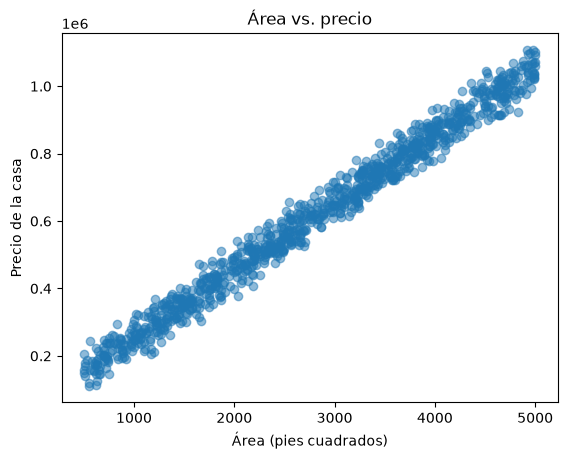

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["Square_Footage"], df["House_Price"], alpha=0.5)
plt.xlabel("Área (pies cuadrados)")
plt.ylabel("Precio de la casa")
plt.title("Área vs. precio")
plt.show()

## 6. Regresión lineal con scikit-learn

`df.drop(columns=...)` devuelve el `DataFrame` sin las columnas indicadas; así separamos las características (`X`) del precio que queremos predecir (`y`). 

La función `train_test_split()` divide los datos: `test_size=0.2` reserva 20 % para prueba y `random_state=42` permite repetir la misma división.

`LinearRegression()` crea el modelo. Su método `fit(X, y)` aprende con los datos de entrenamiento y `predict(X)` genera predicciones para datos nuevos.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df.drop(columns="House_Price")
y = df["House_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
predicciones = modelo.predict(X_test)

### Evaluación

La función `mean_squared_error(reales, predicciones)` calcula el promedio de los errores elevados al cuadrado. 

`np.sqrt()` obtiene su raíz cuadrada para producir el RMSE. 

`r2_score(reales, predicciones)` calcula R²: la proporción de variación explicada; un valor cercano a `1` indica un mejor ajuste.

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.3f}")

RMSE: 10,071.48
R²: 0.998


Para comparar resultados usamos otro `scatter`: cada punto enfrenta un precio real con uno predicho. En una serie o arreglo, los métodos `min()` y `max()` devuelven su menor y mayor valor. Las funciones incorporadas `min()` y `max()` comparan esos límites, y `plt.plot()` dibuja con ellos una diagonal de referencia. Los puntos cercanos a esa línea son mejores predicciones.

### Coeficientes

El atributo `coef_` contiene un coeficiente por característica. Cada uno estima cuánto cambia el precio cuando esa característica aumenta una unidad y las demás permanecen iguales. 

`pd.Series(valores, index=...)` los presenta con el nombre de cada característica.

In [16]:
pd.Series(modelo.coef_, index=X.columns, name="Coeficiente").round(2)

Square_Footage            199.51
Num_Bedrooms            10225.20
Num_Bathrooms            8208.43
Year_Built                993.54
Lot_Size                14885.38
Garage_Size              5146.15
Neighborhood_Quality      115.07
Name: Coeficiente, dtype: float64

### Ahora tú: modelo

1. Quita una característica de `X` con `drop(columns=...)`.
2. Divide y entrena nuevamente el modelo.
3. Calcula el nuevo RMSE y R².
4. Compara los resultados: ¿mejoraron o empeoraron?

In [ ]:
# Escribe tu solución aquí
